# ChatGPT API Early-Fusion Soft-Story Classifier (Colab)

This notebook replaces the local Qwen2-VL setup with the ChatGPT API while keeping the same Google Drive file system and building-level evaluation flow.

In [ ]:
!pip -q install openai pillow pandas tqdm scikit-learn

In [ ]:
import os
import re
import gc
import json
import time
import base64
import random
from collections import defaultdict

import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from openai import OpenAI

## Mount Google Drive and keep the same file system

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## OpenAI API setup
This cell tries Colab Secrets first (`OPENAI_API_KEY`). If not found, it falls back to an environment variable or a manual prompt.

In [ ]:
# Main dataset paths (unchanged from your Colab/Drive layout)
SOFT_DIR = "/content/drive/MyDrive/CEE247C/247C Project/data/soft_story_images/soft_story_images/images"
NON_DIR  = "/content/drive/MyDrive/CEE247C/247C Project/data/non_soft_story_images/images"

SOFT_DIAG = "/content/drive/MyDrive/CEE247C/247C Project/data/soft_story_images/soft_story_images/diagrams"
NON_DIAG  = "/content/drive/MyDrive/CEE247C/247C Project/data/non_soft_story_images/diagrams"

# Few-shot example folders (same file naming convention)
FS_SOFT_IMG_DIR  = "/content/drive/MyDrive/CEE247C/247C Project/data/few_shot/soft_story/images"
FS_SOFT_DIAG_DIR = "/content/drive/MyDrive/CEE247C/247C Project/data/few_shot/soft_story/diagrams"

FS_NON_IMG_DIR   = "/content/drive/MyDrive/CEE247C/247C Project/data/few_shot/non_soft_story/images"
FS_NON_DIAG_DIR  = "/content/drive/MyDrive/CEE247C/247C Project/data/few_shot/non_soft_story/diagrams"

# Output path
FS_OUTPUT_PATH = "/content/drive/MyDrive/CEE247C/247C Project/data/chatgpt_4o_early_fusion_few_shot_results_FINAL.csv"

In [ ]:
api_key = "" #TODO: Replace with your actual API key
try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    pass

if not api_key:
    api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    from getpass import getpass
    api_key = getpass("Enter OPENAI_API_KEY: ")

client = OpenAI(api_key=api_key)

# Recommended model for this task
# MODEL_ID = "gpt-4.1-mini"
MODEL_ID = "gpt-4o"
print("Using model:", MODEL_ID)

Using model: gpt-4o


In [ ]:
def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".webp")
    return sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(exts)
    ])

soft_paths = list_images(SOFT_DIR)
non_paths = list_images(NON_DIR)
soft_diag_paths = list_images(SOFT_DIAG)
non_diag_paths = list_images(NON_DIAG)

print("Soft images:", len(soft_paths))
print("Non images:", len(non_paths))
print("Soft diagrams:", len(soft_diag_paths))
print("Non diagrams:", len(non_diag_paths))
print("Example soft path:", soft_paths[0] if soft_paths else "None found")
print("Example non path:", non_paths[0] if non_paths else "None found")

Soft images: 10680
Non images: 7348
Soft diagrams: 4943
Non diagrams: 3259
Example soft path: /content/drive/MyDrive/CEE247C/247C Project/data/soft_story_images/soft_story_images/images/0_view1.jpg
Example non path: /content/drive/MyDrive/CEE247C/247C Project/data/non_soft_story_images/images/1000_view0.jpg


In [ ]:
num_soft_buildings = len(soft_diag_paths)
num_non_buildings = len(non_diag_paths)
total_num_buildings = num_soft_buildings + num_non_buildings

print("Soft buildings:", num_soft_buildings)
print("Non-soft buildings:", num_non_buildings)
print("Total buildings:", total_num_buildings)

Soft buildings: 4943
Non-soft buildings: 3259
Total buildings: 8202


## Group images by building

In [ ]:
def extract_building_number(filename):
    basename = os.path.basename(filename)

    match = re.match(r"(\d+)_view_?\d+", basename)
    if match:
        return match.group(1)

    match = re.match(r"(\d+)", basename)
    if match:
        return match.group(1)

    return None


def group_images_by_building(image_paths, diagram_paths):
    buildings = defaultdict(lambda: {"views": [], "diagram": None})

    for img_path in image_paths:
        building_num = extract_building_number(img_path)
        if building_num:
            buildings[building_num]["views"].append(img_path)

    for diag_path in diagram_paths:
        building_num = extract_building_number(diag_path)
        if building_num and building_num in buildings:
            buildings[building_num]["diagram"] = diag_path

    return dict(buildings)


soft_buildings = group_images_by_building(soft_paths, soft_diag_paths)
non_buildings  = group_images_by_building(non_paths, non_diag_paths)

print(f"Soft story buildings with views: {len(soft_buildings)}")
print(f"Non-soft story buildings with views: {len(non_buildings)}")

sample_building = list(soft_buildings.keys())[0] if soft_buildings else None
if sample_building:
    print(f"\nSample building {sample_building}:")
    print(f"  Views: {len(soft_buildings[sample_building]['views'])}")
    print(f"  Diagram: {soft_buildings[sample_building]['diagram']}")

Soft story buildings with views: 4683
Non-soft story buildings with views: 3224

Sample building 0:
  Views: 4
  Diagram: /content/drive/MyDrive/CEE247C/247C Project/data/soft_story_images/soft_story_images/diagrams/0.png


In [ ]:
def sample_buildings(buildings_dict, num_samples=500, seed=30000):
    building_numbers = list(buildings_dict.keys())
    if len(building_numbers) < num_samples:
        print(f"Warning: Only {len(building_numbers)} buildings available, less than requested {num_samples}.")
        num_samples = len(building_numbers)

    random.seed(seed)
    sampled_numbers = random.sample(building_numbers, num_samples)
    return {num: buildings_dict[num] for num in sampled_numbers}


sampled_soft_buildings = sample_buildings(soft_buildings, num_samples=70)
sampled_non_buildings  = sample_buildings(non_buildings, num_samples=70)

print(f"Sampled {len(sampled_soft_buildings)} soft story buildings and {len(sampled_non_buildings)} non-soft story buildings for testing.")

Sampled 70 soft story buildings and 70 non-soft story buildings for testing.


## Prompt

In [ ]:
PROMPT = """
You are a structural classification assistant analyzing Google Street View images of a building.

YOUR TASK: Classify the building as SOFT_STORY or NON_SOFT_STORY.
You must always return exactly one of these two labels.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THE STRUCTURAL TEST (ASCE 7 CONCEPT)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Compare the ground floor (floor 1) to the floor above (floor 2).

A soft story occurs when the ground floor has substantially less lateral
stiffness than the floor above. Since stiffness cannot be measured directly
from an image, use visible solid wall area as a proxy.

If the ground floor is much more open than the floor above, the building
may be a soft-story structure.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATURES THAT REDUCE GROUND-FLOOR STIFFNESS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Examples include:
- multiple vehicle-width garage bays
- tuck-under parking
- open columns or pilotis with little or no infill walls
- large commercial storefront glazing
- ground floor dominated by large open bays

These features often create a clear vertical discontinuity between floors.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATURES THAT DO NOT INDICATE SOFT STORY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Do NOT classify a building as SOFT_STORY simply because it has:
- residential windows
- standard entry doors
- balconies or stoops
- decorative arches
- a single garage door in an otherwise solid facade

Many typical residential buildings include these elements and are still
NON_SOFT_STORY.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LABEL DEFINITIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SOFT_STORY:
The ground floor is clearly much more open than the floor above.
Large openings dominate the ground floor facade and the difference
between floors is visually obvious.

NON_SOFT_STORY:
The ground floor and the floor above are similarly enclosed.
The facade still contains substantial solid wall area even if
doors, windows, or one garage opening are present.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEW-SHOT EXAMPLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The examples shown above are ground truth verified by structural engineers.

Study both the SOFT_STORY and NON_SOFT_STORY examples carefully.
Focus on how the ground-floor enclosure compares to the floor above.

When analyzing a new building, compare it to the closest example.
If it visually resembles the SOFT_STORY examples, output SOFT_STORY.
If it visually resembles the NON_SOFT_STORY examples, output NON_SOFT_STORY.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OUTPUT FORMAT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Return exactly one of the following strings and nothing else:
SOFT_STORY
NON_SOFT_STORY
"""

In [ ]:
# PROMPT = """
# You are a structural classification assistant analyzing Google Street View images of a building.

# YOUR TASK: Classify as SOFT_STORY or NON_SOFT_STORY. Always return exactly one.

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# THE TEST
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Compare floor 1 to floor 2 across ALL views.
# SOFT_STORY if floor 1 has less than ~70% of the solid wall area of floor 2.
# Default to SOFT_STORY when in doubt — misclassifying a soft story as
# non-soft is the costlier error.

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# COUNTS as stiffness-reducing:
# vehicle-width garages, tuck-under parking, pilotis, floor-to-ceiling commercial glazing.

# DOES NOT count:
# entry doors, residential windows, single garage door in solid facade, stoops, arches.

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DECISION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SOFT_STORY     → ground floor clearly more open than floor above, OR uncertain.
# NON_SOFT_STORY → ground floor is confidently as solid as floor above.
#                  Only call this if it clearly matches a NON_SOFT_STORY example.

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FEW-SHOT EXAMPLES ABOVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ground truth verified by structural engineers.
# Match the new building to the closest example.
# NON_SOFT_STORY requires a confident visual match to a NON_SOFT example.

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OUTPUT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Return exactly one of the following strings and nothing else:
# SOFT_STORY
# NON_SOFT_STORY
# """

## Few-shot configuration

In [ ]:
FEW_SHOT_K = 5               # number of buildings per class for demonstrations
MAX_VIEWS_PER_EXAMPLE = 3    # keep example token/image load manageable
MAX_QUERY_VIEWS = 6          # query building view cap
SKIP_EXAMPLE_DIAGRAMS = False
REQUEST_PAUSE_SEC = 0.0      # increase if you want slower pacing

In [ ]:
def load_few_shot_examples(img_dir, diag_dir, label, k, max_views=None):
    buildings = group_images_by_building(
        list_images(img_dir),
        list_images(diag_dir)
    )

    examples = []
    for bid, data in list(buildings.items())[:k]:
        if not data["views"]:
            print(f"  [SKIP] Building {bid} — no view images found")
            continue

        views = data["views"][:max_views] if max_views else data["views"]
        examples.append({
            "building_id": bid,
            "views": views,
            "diagram": data["diagram"],
            "label": label
        })

    return examples


fs_soft_examples = load_few_shot_examples(
    FS_SOFT_IMG_DIR, FS_SOFT_DIAG_DIR, "SOFT_STORY", FEW_SHOT_K, MAX_VIEWS_PER_EXAMPLE
)
fs_non_examples = load_few_shot_examples(
    FS_NON_IMG_DIR, FS_NON_DIAG_DIR, "NON_SOFT_STORY", FEW_SHOT_K, MAX_VIEWS_PER_EXAMPLE
)

few_shot_examples = fs_soft_examples + fs_non_examples

print("Few-shot examples loaded:")
print(f"  SOFT_STORY    : {len(fs_soft_examples)} buildings")
print(f"  NON_SOFT_STORY: {len(fs_non_examples)} buildings")

for ex in few_shot_examples:
    diag_ok = "✓" if ex["diagram"] else "✗ (missing)"
    print(f"  [{ex['label']}] id={ex['building_id']}  views={len(ex['views'])}  diagram={diag_ok}")

Few-shot examples loaded:
  SOFT_STORY    : 5 buildings
  NON_SOFT_STORY: 5 buildings
  [SOFT_STORY] id=461  views=2  diagram=✓
  [SOFT_STORY] id=579  views=2  diagram=✓
  [SOFT_STORY] id=617  views=2  diagram=✓
  [SOFT_STORY] id=635  views=2  diagram=✓
  [SOFT_STORY] id=847  views=3  diagram=✓
  [NON_SOFT_STORY] id=168  views=3  diagram=✓
  [NON_SOFT_STORY] id=27  views=2  diagram=✓
  [NON_SOFT_STORY] id=443  views=2  diagram=✓
  [NON_SOFT_STORY] id=74  views=3  diagram=✓
  [NON_SOFT_STORY] id=8  views=3  diagram=✓


## API helpers

In [ ]:
def encode_image_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def guess_mime_type(image_path):
    ext = os.path.splitext(image_path)[1].lower()
    if ext == ".png":
        return "image/png"
    if ext == ".webp":
        return "image/webp"
    return "image/jpeg"


def image_part(image_path):
    mime = guess_mime_type(image_path)
    b64 = encode_image_base64(image_path)
    return {
        "type": "input_image",
        "image_url": f"data:{mime};base64,{b64}"
    }


def parse_response(raw_text):
    txt = (raw_text or "").strip().upper()
    txt = re.sub(r"[^A-Z_\n ]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()

    if "NON_SOFT_STORY" in txt:
        return "NON_SOFT_STORY"
    if "SOFT_STORY" in txt:
        return "SOFT_STORY"
    return "PARSE_ERROR"

In [ ]:
FEW_SHOT_INTRO = """You are a structural classification assistant.
Below are confirmed SOFT_STORY and NON_SOFT_STORY examples.
Study each example carefully and pay attention to how open or enclosed the ground floor is
relative to the upper floors, and how the targeting diagram relates to each set of views.

After the examples you will be given a NEW building to classify.
Apply exactly the same reasoning to the new building.
"""

FEW_SHOT_EXAMPLE_HEADER = """━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXAMPLE {idx} — Label: {label}
  {n_views} street-view image(s){diag_note} follow.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

FEW_SHOT_QUERY_HEADER = """━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NEW BUILDING TO CLASSIFY
  {n_views} street-view image(s){diag_note} follow.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""


def build_few_shot_content(view_paths, diagram_path, examples, prompt):
    content = []
    content.append({"type": "input_text", "text": FEW_SHOT_INTRO})

    for idx, ex in enumerate(examples, start=1):
        has_diag = bool(ex["diagram"] and os.path.exists(ex["diagram"]) and not SKIP_EXAMPLE_DIAGRAMS)
        diag_note = " + 1 targeting diagram" if has_diag else " (no diagram available)"

        content.append({
            "type": "input_text",
            "text": FEW_SHOT_EXAMPLE_HEADER.format(
                idx=idx,
                label=ex["label"],
                n_views=len(ex["views"]),
                diag_note=diag_note
            )
        })

        for vp in ex["views"]:
            content.append(image_part(vp))

        if has_diag:
            content.append(image_part(ex["diagram"]))

        content.append({
            "type": "input_text",
            "text": f"Confirmed label for example {idx}: {ex['label']}"
        })

    has_query_diag = bool(diagram_path and os.path.exists(diagram_path))
    diag_note = " + 1 targeting diagram" if has_query_diag else " (no diagram available)"

    content.append({
        "type": "input_text",
        "text": FEW_SHOT_QUERY_HEADER.format(
            n_views=len(view_paths),
            diag_note=diag_note
        )
    })

    for vp in view_paths:
        content.append(image_part(vp))

    if has_query_diag:
        content.append(image_part(diagram_path))

    content.append({"type": "input_text", "text": prompt})
    return content

In [ ]:
def classify_building_few_shot(view_paths, diagram_path, examples, prompt, model=MODEL_ID):
    try:
        content = build_few_shot_content(view_paths, diagram_path, examples, prompt)

        response = client.responses.create(
            model=model,
            input=[{
                "role": "user",
                "content": content
            }],
            temperature=0,
            max_output_tokens=32
        )

        raw_response = response.output_text.strip()
        label = parse_response(raw_response)

        if label == "PARSE_ERROR":
            print(f"  [WARN] Unexpected model output: {repr(raw_response)}")

        return label

    except Exception as e:
        print(f"  [ERROR] {e}")
        return "ERROR"

In [ ]:
def evaluate_buildings_few_shot(building_dict, ground_truth_label, examples, prompt, model=MODEL_ID):
    example_ids = {str(ex["building_id"]) for ex in examples}

    results = {}
    skipped = 0

    for building_id, data in tqdm(building_dict.items()):
        if str(building_id) in example_ids:
            skipped += 1
            continue

        query_views = data["views"][:MAX_QUERY_VIEWS] if MAX_QUERY_VIEWS else data["views"]

        label = classify_building_few_shot(
            query_views,
            data["diagram"],
            examples,
            prompt,
            model=model
        )

        results[building_id] = {
            "prediction": label,
            "ground_truth": ground_truth_label,
            "correct": label == ground_truth_label
        }

        if REQUEST_PAUSE_SEC > 0:
            time.sleep(REQUEST_PAUSE_SEC)

    correct = sum(r["correct"] for r in results.values())
    total = len(results)

    print(f"\nSkipped {skipped} few-shot example building(s).")
    if total:
        print(f"Accuracy: {correct}/{total} ({100 * correct / total:.1f}%)")
    else:
        print("No buildings evaluated.")

    return results

## Smoke test

In [ ]:
example_ids = {str(ex["building_id"]) for ex in few_shot_examples}
test_id = next(
    bid for bid in non_buildings
    if str(bid) not in example_ids
)
test_data = non_buildings[test_id]
query_views = test_data["views"][:MAX_QUERY_VIEWS]

print(f"Few-shot smoke test on building {test_id}...")
print(f"Using {len(query_views)} query views and {len(few_shot_examples)} few-shot examples")

result = classify_building_few_shot(
    query_views,
    test_data["diagram"],
    few_shot_examples,
    PROMPT
)

print("Prediction   :", result)
print("Ground truth :", "NON_SOFT_STORY")

Few-shot smoke test on building 1000...
Using 2 query views and 10 few-shot examples
Prediction   : SOFT_STORY
Ground truth : NON_SOFT_STORY


In [ ]:
example_ids = {str(ex["building_id"]) for ex in few_shot_examples}
test_id = next(
    bid for bid in soft_buildings
    if str(bid) not in example_ids
)
test_data = soft_buildings[test_id]
query_views = test_data["views"][:MAX_QUERY_VIEWS]

print(f"Few-shot smoke test on building {test_id}...")
print(f"Using {len(query_views)} query views and {len(few_shot_examples)} few-shot examples")

result = classify_building_few_shot(
    query_views,
    test_data["diagram"],
    few_shot_examples,
    PROMPT
)

print("Prediction   :", result)
print("Ground truth :", "SOFT_STORY")

Few-shot smoke test on building 0...
Using 4 query views and 10 few-shot examples
Prediction   : NON_SOFT_STORY
Ground truth : SOFT_STORY


## Full evaluation

In [ ]:
print("=" * 60)
print("FEW-SHOT: EVALUATING NON-SOFT STORY BUILDINGS")
print("=" * 60)
fs_non_results = evaluate_buildings_few_shot(
    sampled_non_buildings,
    "NON_SOFT_STORY",
    few_shot_examples,
    PROMPT
)

print("=" * 60)
print("FEW-SHOT: EVALUATING SOFT STORY BUILDINGS")
print("=" * 60)
fs_soft_results = evaluate_buildings_few_shot(
    sampled_soft_buildings,
    "SOFT_STORY",
    few_shot_examples,
    PROMPT
)

fs_all_results = []
for building_id, data in {**fs_soft_results, **fs_non_results}.items():
    fs_all_results.append({
        "building_number": building_id,
        "predicted": data["prediction"],
        "ground_truth": data["ground_truth"],
        "correct": data["correct"]
    })

fs_results_df = pd.DataFrame(fs_all_results)

print("\n" + "=" * 60)
print(f"Total buildings evaluated : {len(fs_results_df)}")
print(f"Overall accuracy          : {fs_results_df['correct'].mean():.1%}")

print("\nPrediction distribution:")
print(fs_results_df["predicted"].value_counts().to_string())

print("\nAccuracy by category:")
for gt in fs_results_df["ground_truth"].unique():
    sub = fs_results_df[fs_results_df["ground_truth"] == gt]
    print(f"  {gt}: {sub['correct'].sum()}/{len(sub)} ({sub['correct'].mean():.1%})")

FEW-SHOT: EVALUATING NON-SOFT STORY BUILDINGS


 13%|█▎        | 9/70 [11:36<1:07:27, 66.35s/it]

  [ERROR] Error code: 429 - {'error': {'message': 'Request too large for gpt-4o in organization org-tMlH1vEA29F4jQE1Yb39pW2L on tokens per min (TPM): Limit 30000, Requested 30600. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}


100%|██████████| 70/70 [1:39:28<00:00, 85.26s/it]



Skipped 0 few-shot example building(s).
Accuracy: 38/70 (54.3%)
FEW-SHOT: EVALUATING SOFT STORY BUILDINGS


100%|██████████| 70/70 [1:40:32<00:00, 86.18s/it]


Skipped 0 few-shot example building(s).
Accuracy: 46/70 (65.7%)

Total buildings evaluated : 140
Overall accuracy          : 60.0%

Prediction distribution:
predicted
SOFT_STORY        77
NON_SOFT_STORY    62
ERROR              1

Accuracy by category:
  SOFT_STORY: 46/70 (65.7%)
  NON_SOFT_STORY: 38/70 (54.3%)


In [ ]:
print(classification_report(
    fs_results_df["ground_truth"],
    fs_results_df["predicted"],
    digits=4
))

                precision    recall  f1-score   support

         ERROR     0.0000    0.0000    0.0000         0
NON_SOFT_STORY     0.6129    0.5429    0.5758        70
    SOFT_STORY     0.5974    0.6571    0.6259        70

      accuracy                         0.6000       140
     macro avg     0.4034    0.4000    0.4005       140
  weighted avg     0.6052    0.6000    0.6008       140



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
fs_results_df.to_csv(FS_OUTPUT_PATH, index=False)
print(f"Few-shot results saved to: {FS_OUTPUT_PATH}")

Few-shot results saved to: /content/drive/MyDrive/CEE247C/247C Project/data/chatgpt_4o_early_fusion_few_shot_results_FINAL.csv


## Optional: save a timestamped backup too

In [ ]:
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
backup_output_path = FS_OUTPUT_PATH.replace(".csv", f"_{timestamp}.csv")
fs_results_df.to_csv(backup_output_path, index=False)
print(f"Backup results saved to: {backup_output_path}")

Backup results saved to: /content/drive/MyDrive/CEE247C/247C Project/data/chatgpt_4o_early_fusion_few_shot_results_FINAL_20260310_221122.csv


In [ ]:
# fs_results_df_old = pd.read_csv("")
# combine fs_results_df and fs_results_df and calculate the overall accuracy, recall for soft story, and F1 score which is the average of F1 scores evaluated for each class


First, I'll attempt to load the `fs_results_df_old` from the specified CSV path. Please ensure the file `chatgpt_4o_early_fusion_few_shot_results.csv` exists at this location. If not, you may need to adjust the path or upload the file.

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Construct the path for the old results, assuming it's in the same directory as the new results' output
old_results_path = '/content/drive/MyDrive/CEE247C/247C Project/data/chatgpt_4o_early_fusion_few_shot_results.csv'

try:
    fs_results_df_old = pd.read_csv(old_results_path)
    print(f"Successfully loaded old results from: {old_results_path}")

    # Combine the current and old results
    combined_results_df = pd.concat([fs_results_df_old, fs_results_df], ignore_index=True)
    print(f"Combined {len(fs_results_df_old)} old results with {len(fs_results_df)} new results, total: {len(combined_results_df)} records.")

    # Calculate overall accuracy
    overall_accuracy = combined_results_df['correct'].mean()
    print(f"\nOverall accuracy of combined results: {overall_accuracy:.1%}")

    # Generate classification report for detailed metrics
    print("\nDetailed classification report for combined results:")
    print(classification_report(
        combined_results_df["ground_truth"],
        combined_results_df["predicted"],
        digits=4
    ))

except FileNotFoundError:
    print(f"Error: The file '{old_results_path}' was not found. Please ensure the CSV file exists at the specified path.")
except Exception as e:
    print(f"An error occurred while processing: {e}")

Successfully loaded old results from: /content/drive/MyDrive/CEE247C/247C Project/data/chatgpt_4o_early_fusion_few_shot_results.csv
Combined 59 old results with 140 new results, total: 199 records.

Overall accuracy of combined results: 58.3%

Detailed classification report for combined results:
                precision    recall  f1-score   support

         ERROR     0.0000    0.0000    0.0000         0
NON_SOFT_STORY     0.6049    0.4900    0.5414       100
    SOFT_STORY     0.5726    0.6768    0.6204        99

      accuracy                         0.5829       199
     macro avg     0.3925    0.3889    0.3873       199
  weighted avg     0.5889    0.5829    0.5807       199



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Let's generate a confusion matrix to get a clearer picture of the model's performance on each class.

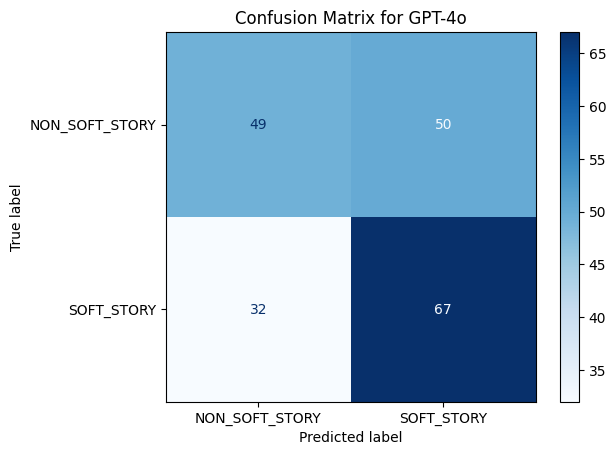

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Filter out 'ERROR' predictions if any exist, as they are not valid classes for the confusion matrix
filtered_df = combined_results_df[combined_results_df['predicted'] != 'ERROR']

y_true = filtered_df["ground_truth"]
y_pred = filtered_df["predicted"]

# Get unique labels to ensure consistent order in the confusion matrix
labels = sorted(y_true.unique())

cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for GPT-4o')
plt.show()

## results for gpt-4.1-mini

In [ ]:
fs_results_df_gpt41 = pd.read_csv("/content/drive/MyDrive/CEE247C/247C Project/data/chatgpt_early_fusion_few_shot_results.csv")

In [ ]:
# Combine the current and old results
combined_results_df = fs_results_df_gpt41
print(f"Combined {len(fs_results_df_old)} old results with {len(fs_results_df)} new results, total: {len(combined_results_df)} records.")

# Calculate overall accuracy
overall_accuracy = combined_results_df['correct'].mean()
print(f"\nOverall accuracy of combined results: {overall_accuracy:.1%}")

# Generate classification report for detailed metrics
print("\nDetailed classification report for combined results:")
print(classification_report(
    combined_results_df["ground_truth"],
    combined_results_df["predicted"],
    digits=4
))

Combined 59 old results with 140 new results, total: 196 records.

Overall accuracy of combined results: 57.7%

Detailed classification report for combined results:
                precision    recall  f1-score   support

NON_SOFT_STORY     0.5957    0.5600    0.5773       100
   PARSE_ERROR     0.0000    0.0000    0.0000         0
    SOFT_STORY     0.5644    0.5938    0.5787        96

      accuracy                         0.5765       196
     macro avg     0.3867    0.3846    0.3853       196
  weighted avg     0.5804    0.5765    0.5780       196



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


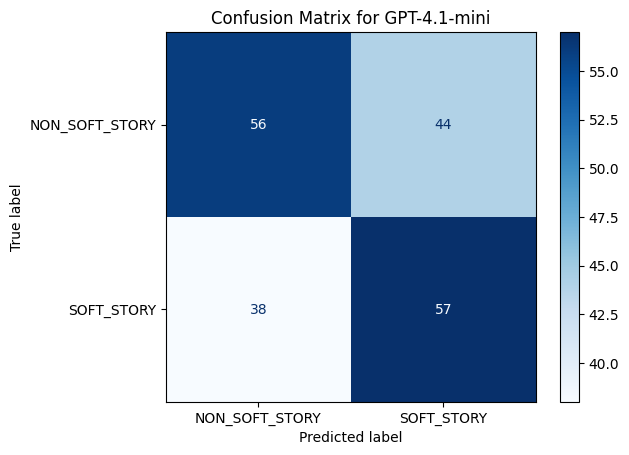

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Filter out 'ERROR' predictions if any exist, as they are not valid classes for the confusion matrix
filtered_df = combined_results_df[combined_results_df['predicted'] != 'ERROR']

y_true = filtered_df["ground_truth"]
y_pred = filtered_df["predicted"]

# Get unique labels to ensure consistent order in the confusion matrix
labels = sorted(y_true.unique())

cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for GPT-4.1-mini')
plt.show()

### for Qwen-7B

In [ ]:
fs_results_df_qwen = pd.read_csv("/content/drive/MyDrive/CEE247C/247C Project/data/qwen_early_fusion_few_shot_results.csv")

In [ ]:
# Combine the current and old results
combined_results_df = fs_results_df_qwen
print(f"Combined {len(fs_results_df_old)} old results with {len(fs_results_df)} new results, total: {len(combined_results_df)} records.")

# Calculate overall accuracy
overall_accuracy = combined_results_df['correct'].mean()
print(f"\nOverall accuracy of combined results: {overall_accuracy:.1%}")

# Generate classification report for detailed metrics
print("\nDetailed classification report for combined results:")
print(classification_report(
    combined_results_df["ground_truth"],
    combined_results_df["predicted"],
    digits=4
))

Combined 59 old results with 140 new results, total: 931 records.

Overall accuracy of combined results: 47.9%

Detailed classification report for combined results:
                precision    recall  f1-score   support

NON_SOFT_STORY     0.7586    0.0440    0.0832       500
    SOFT_STORY     0.4701    0.9838    0.6362       431

      accuracy                         0.4791       931
     macro avg     0.6143    0.5139    0.3597       931
  weighted avg     0.6250    0.4791    0.3392       931



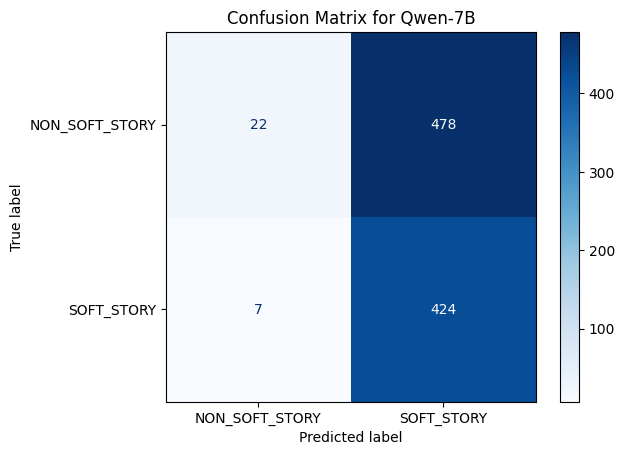

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Filter out 'ERROR' predictions if any exist, as they are not valid classes for the confusion matrix
filtered_df = combined_results_df[combined_results_df['predicted'] != 'ERROR']

y_true = filtered_df["ground_truth"]
y_pred = filtered_df["predicted"]

# Get unique labels to ensure consistent order in the confusion matrix
labels = sorted(y_true.unique())

cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Qwen-7B')
plt.show()